# Hola

En esta notebook se busca maximizar la varianza entre las imagenes cortadas en cuadrantes.

Se entrena una red para cada cuadrante y al final se usa un clasificador RBF con las probabilidades de las 4 redes como entradas.

No se si la maximizacion de la varianza ayude o no, se pone a prueba en esta notebook, se hace cropping de los cuadrantes, sin aplicar color jittering. Le hice 100 epocas para asegurarme que no fuera por eso, resulta que empeoro el rendimiento. Supongo que el problema es el cropping.

Tengo que volver a encontrar la forma de maximizar la varianza, pero ahora sin hacer cropping.

# Loading the DataSet

In [1]:
from torchvision import transforms, datasets
from torch.utils.data import DataLoader, WeightedRandomSampler
import torch, numpy as np

In [2]:
painter_to_genre = {
    "Joan": "Surrealismo",
    "Salvador": "Surrealismo",
    "Rene": "Surrealismo",
    "Pablo": "Cubismo",
    "Jackson": "Expresionismo abstracto",
    "Rembrandt": "Barroco",
    "Caravaggio": "Barroco",
    "Camille": "Impresionismo",
    "Alfred": "Impresionismo",
    "Claude": "Impresionismo",
    "Vincent": "Impresionismo",  
}

genre_to_label = {
    "Surrealismo": 0,
    "Cubismo": 1,
    "Expresionismo abstracto": 2,
    "Barroco": 3,
    "Impresionismo": 4,
}

In [3]:
from pathlib import Path
import pandas as pd

root = Path("08 Clasificacion de Movimientos Artisticos/data")

# recoge todos los .jpg (ajusta extensiones si hay .png, etc.)
paths = sorted(root.glob("*.jpg"))

rows = []
for p in paths:
    stem = p.stem  # 'Joan_Miro_001'
    # ejemplo simple: pintor = todo menos la parte final si es número
    painter = stem.split("_")[0]
    genre = painter_to_genre[painter]
    label = genre_to_label[genre]

    rows.append({
        "path": str(p),
        "painter": painter,
        "genre": genre,
        "label": label,
    })

df = pd.DataFrame(rows)

In [4]:
print(df['genre'].value_counts())
df.head()

genre
Impresionismo              75
Surrealismo                50
Barroco                    30
Cubismo                    30
Expresionismo abstracto    15
Name: count, dtype: int64


,path,painter,genre,label
0,08 Clasificacion de Movimientos Artisticos\dat...,Alfred,Impresionismo,4
1,08 Clasificacion de Movimientos Artisticos\dat...,Alfred,Impresionismo,4
2,08 Clasificacion de Movimientos Artisticos\dat...,Alfred,Impresionismo,4
3,08 Clasificacion de Movimientos Artisticos\dat...,Alfred,Impresionismo,4
4,08 Clasificacion de Movimientos Artisticos\dat...,Alfred,Impresionismo,4


In [5]:
from torch.utils.data import Dataset
from PIL import Image

class PaintingDataset(Dataset):
    def __init__(self, df, transform=None):
        self.df = df.reset_index(drop=True)
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        img = Image.open(row["path"]).convert("RGB")
        y = int(row["label"])
        if self.transform is not None:
            img = self.transform(img)
        return img, y


# Data Engineering 😜

## Maximizing Variance with ColorJitter

In [6]:
import torch
from PIL import Image

def compute_mean_std_from_df(df, transform):
    channel_sum = torch.zeros(3)
    channel_sq_sum = torch.zeros(3)
    n_pixels = 0

    for path in df["path"]:
        img = Image.open(path).convert("RGB")
        x = transform(img)           # C×H×W, in [0,1]

        B, C, H, W = 1, *x.shape     # fake batch size 1
        n = B * H * W

        channel_sum    += x.view(C, -1).sum(dim=1)
        channel_sq_sum += (x**2).view(C, -1).sum(dim=1)
        n_pixels       += n

    mean = channel_sum / n_pixels
    var  = channel_sq_sum / n_pixels - mean ** 2
    std  = torch.sqrt(var + 1e-8)
    return mean, std

In [71]:
import random

def sample_params():
    return {
        "contrast":   random.uniform(0.0, 0.6),
        "saturation": random.uniform(0.0, 0.6),
        "brightness": random.uniform(0.0, 0.6),
        "hue":        random.uniform(0.0, 0.15),
    }

best = None
best_score = -float("inf")

for i in range(50):  # or 100, as budget allows
    p = sample_params()
    stat = transforms.Compose([
        transforms.Resize((128, 128)),
        transforms.ColorJitter(
            contrast=p["contrast"],
            saturation=p["saturation"],
            brightness=p["brightness"],
            hue=p["hue"],
        ),
        transforms.ToTensor(),
    ])

    mean, std = compute_mean_std_from_df(df, stat)  # use a subset!
    score = torch.norm(std).item()  # or your better objective

    if score > best_score:
        best_score = score
        best = {**p, "score": score}

    print(i, best)


0 {'contrast': 0.10740313052040153, 'saturation': 0.1021351653346111, 'brightness': 0.38047508518445655, 'hue': 0.0253971591144234, 'score': 0.4470843970775604}
1 {'contrast': 0.10740313052040153, 'saturation': 0.1021351653346111, 'brightness': 0.38047508518445655, 'hue': 0.0253971591144234, 'score': 0.4470843970775604}
2 {'contrast': 0.10740313052040153, 'saturation': 0.1021351653346111, 'brightness': 0.38047508518445655, 'hue': 0.0253971591144234, 'score': 0.4470843970775604}
3 {'contrast': 0.10740313052040153, 'saturation': 0.1021351653346111, 'brightness': 0.38047508518445655, 'hue': 0.0253971591144234, 'score': 0.4470843970775604}
4 {'contrast': 0.10740313052040153, 'saturation': 0.1021351653346111, 'brightness': 0.38047508518445655, 'hue': 0.0253971591144234, 'score': 0.4470843970775604}
5 {'contrast': 0.1206071762725515, 'saturation': 0.15125127356845583, 'brightness': 0.5504280923276234, 'hue': 0.019901269109075952, 'score': 0.4702908992767334}
6 {'contrast': 0.1206071762725515

In [72]:
best

{'contrast': 0.04958954582352304,
 'saturation': 0.1860411427286125,
 'brightness': 0.5600333566106395,
 'hue': 0.1318715676608575,
 'score': 0.5113227963447571}

In [74]:
# save the best_params dictionary to a file
import json
with open('08 Clasificacion de Movimientos Artisticos/info/best_params_full_image.json', 'w') as f:
    json.dump(best, f, indent=4)

In [75]:
import json
with open('08 Clasificacion de Movimientos Artisticos/info/best_params_full_image.json', 'r') as f:
    best = json.load(f)

In [90]:
from torchvision import transforms

contrast = best['contrast']
saturation = best['saturation']
brightness = best['brightness']
hue = best['hue']

# stat means and std transforms with best parameters
stat_ul = transforms.Compose([
    # QuadrantCrop("ul"),
    transforms.Resize((128, 128)),
    transforms.ColorJitter(contrast=contrast, saturation=saturation, brightness=brightness, hue=hue),
    transforms.ToTensor(),
])

stat_ur = transforms.Compose([
    # QuadrantCrop("ur"),
    transforms.Resize((128, 128)),
    transforms.ColorJitter(contrast=contrast, saturation=saturation, brightness=brightness, hue=hue),
    transforms.ToTensor(),
])

stat_ll = transforms.Compose([
    # QuadrantCrop("ll"),
    transforms.Resize((128, 128)),
    transforms.ColorJitter(contrast=contrast, saturation=saturation, brightness=brightness, hue=hue),
    transforms.ToTensor(),
])

stat_lr = transforms.Compose([
    #QuadrantCrop("lr"),
    transforms.Resize((128, 128)),
    transforms.ColorJitter(contrast=contrast, saturation=saturation, brightness=brightness, hue=hue),
    transforms.ToTensor(),
])

## Get Mean and Std ef each cuadrant

In [77]:
# stat_ul, stat_ur, stat_ll, stat_lr defined as before (QuadrantCrop + Resize + ToTensor)
mean_ul, std_ul = compute_mean_std_from_df(df, stat_ul)
mean_ur, std_ur = compute_mean_std_from_df(df, stat_ur)
mean_ll, std_ll = compute_mean_std_from_df(df, stat_ll)
mean_lr, std_lr = compute_mean_std_from_df(df, stat_lr)

print("UL:", mean_ul, std_ul)
print("UR:", mean_ur, std_ur)
print("LL:", mean_ll, std_ll)
print("LR:", mean_lr, std_lr)


UL: tensor([0.4834, 0.4396, 0.3920]) tensor([0.2852, 0.2868, 0.2781])
UR: tensor([0.4842, 0.4351, 0.3846]) tensor([0.2850, 0.2833, 0.2683])
LL: tensor([0.4646, 0.4159, 0.3687]) tensor([0.2790, 0.2770, 0.2565])
LR: tensor([0.4828, 0.4428, 0.3877]) tensor([0.2752, 0.2790, 0.2592])


In [91]:
# stat_ul, stat_ur, stat_ll, stat_lr defined as before (QuadrantCrop + Resize + ToTensor)
mean_ul, std_ul = compute_mean_std_from_df(df, stat_ul)
mean_ur, std_ur = compute_mean_std_from_df(df, stat_ur)
mean_ll, std_ll = compute_mean_std_from_df(df, stat_ll)
mean_lr, std_lr = compute_mean_std_from_df(df, stat_lr)

print("UL:", mean_ul, std_ul)
print("UR:", mean_ur, std_ur)
print("LL:", mean_ll, std_ll)
print("LR:", mean_lr, std_lr)


UL: tensor([0.4714, 0.4364, 0.3778]) tensor([0.2764, 0.2778, 0.2642])
UR: tensor([0.4812, 0.4368, 0.3793]) tensor([0.2750, 0.2750, 0.2682])
LL: tensor([0.4544, 0.4206, 0.3653]) tensor([0.2766, 0.2781, 0.2677])
LR: tensor([0.4857, 0.4577, 0.3890]) tensor([0.2823, 0.2853, 0.2752])


Results no color jittering
```bash
UL: tensor([0.5137, 0.4741, 0.4183]) tensor([0.2633, 0.2578, 0.2585])
UR: tensor([0.5185, 0.4773, 0.4243]) tensor([0.2598, 0.2562, 0.2641])
LL: tensor([0.4776, 0.4220, 0.3525]) tensor([0.2496, 0.2390, 0.2269])
LR: tensor([0.4764, 0.4229, 0.3585]) tensor([0.2504, 0.2425, 0.2359])
```

Results with color jittering `contrast=1.5, saturation=1.5`
```bash
UL: tensor([0.5165, 0.4690, 0.4055]) tensor([0.3070, 0.2975, 0.3078])
UR: tensor([0.5172, 0.4707, 0.4255]) tensor([0.2931, 0.2896, 0.3039])
LL: tensor([0.4834, 0.4192, 0.3336]) tensor([0.2983, 0.2766, 0.2674])
LR: tensor([0.4832, 0.4193, 0.3363]) tensor([0.3066, 0.2873, 0.2882])
```

In [78]:
# save mean_ul, std_ul, mean_ur, std_ur, mean_ll, std_ll, mean_lr, std_lr to json
mean_std = {
    "mean_ul": mean_ul.tolist(),
    "std_ul": std_ul.tolist(),
    "mean_ur": mean_ur.tolist(),
    "std_ur": std_ur.tolist(),
    "mean_ll": mean_ll.tolist(),
    "std_ll": std_ll.tolist(),
    "mean_lr": mean_lr.tolist(),
    "std_lr": std_lr.tolist(),
}

# save to file
import json
with open('08 Clasificacion de Movimientos Artisticos/info/mean_std_full_image.json', 'w') as f:
    json.dump(mean_std, f, indent=4)

In [79]:
# read mean_ul, std_ul, mean_ur, std_ur, mean_ll, std_ll, mean_lr, std_lr from json
import json
with open('08 Clasificacion de Movimientos Artisticos/info/mean_std_full_image.json', 'r') as f:
    mean_std = json.load(f)

# convert to numpy arrays
mean_ul = np.array(mean_std["mean_ul"])
std_ul = np.array(mean_std["std_ul"])
mean_ur = np.array(mean_std["mean_ur"])
std_ur = np.array(mean_std["std_ur"])
mean_ll = np.array(mean_std["mean_ll"])
std_ll = np.array(mean_std["std_ll"])
mean_lr = np.array(mean_std["mean_lr"])
std_lr = np.array(mean_std["std_lr"])

In [85]:
transf_ul = transforms.Compose([
    # QuadrantCrop("ul"),
    transforms.Resize((128, 128)),
    transforms.ColorJitter(contrast=contrast, saturation=saturation, brightness=brightness, hue=hue),
    transforms.ToTensor(),
    transforms.Normalize(mean=mean_ul.tolist(), std=std_ul.tolist()),
])

transf_ur = transforms.Compose([
    #QuadrantCrop("ur"),
    transforms.Resize((128, 128)),
    transforms.ColorJitter(contrast=contrast, saturation=saturation, brightness=brightness, hue=hue),
    transforms.ToTensor(),
    transforms.Normalize(mean=mean_ur.tolist(), std=std_ur.tolist()),
])

transf_ll = transforms.Compose([
    # QuadrantCrop("ll"),
    transforms.Resize((128, 128)),
    transforms.ColorJitter(contrast=contrast, saturation=saturation, brightness=brightness, hue=hue),
    transforms.ToTensor(),
    transforms.Normalize(mean=mean_ll.tolist(), std=std_ll.tolist()),
])

transf_lr = transforms.Compose([
    # QuadrantCrop("lr"),
    transforms.Resize((128, 128)),
    transforms.ColorJitter(contrast=contrast, saturation=saturation, brightness=brightness, hue=hue),
    transforms.ToTensor(),
    transforms.Normalize(mean=mean_lr.tolist(), std=std_lr.tolist()),
])


# Visualización de imágenes con los mejores parámetros encontrados

In [86]:
from sklearn.model_selection import train_test_split

train_df, val_df = train_test_split(df, test_size=0.1, stratify=df['label'], random_state=863)

In [87]:
train_ul = PaintingDataset(train_df, transform=transf_ul)
train_ur = PaintingDataset(train_df, transform=transf_ur)
train_ll = PaintingDataset(train_df, transform=transf_ll)
train_lr = PaintingDataset(train_df, transform=transf_lr)

import torch.utils.data
train_ds = torch.utils.data.ConcatDataset([train_ul, train_ur, train_ll, train_lr])

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.0951248..1.7206421].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.84373593..2.2648659].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.2013143..0.7029564].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.2130052..0.94038725].


Label: 4 Impresionismo


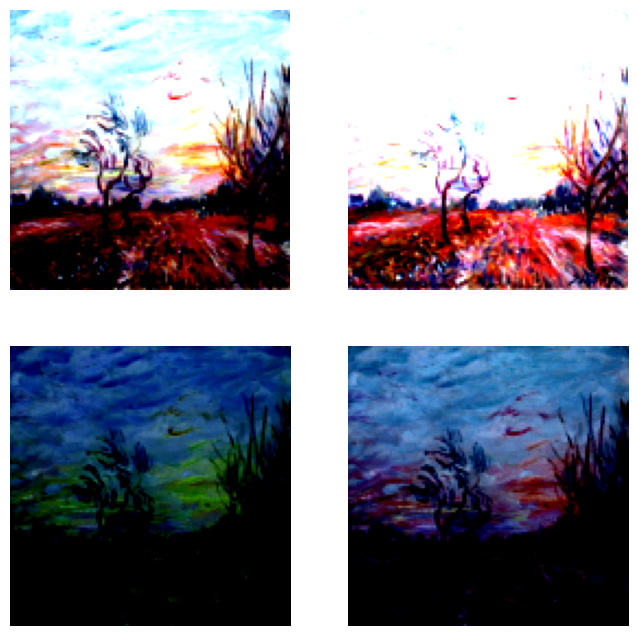

In [98]:
import random
r = random.randint(0, len(train_ul)-1)
img_ul, y = train_ul[r]
img_ur, y = train_ur[r]
img_ll, y = train_ll[r]
img_lr, y = train_lr[r]

print("Label:", y, train_df.iloc[r]["genre"])


import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 2, figsize=(8, 8))

axes[0,0].imshow((img_ul).permute(1,2,0).cpu().numpy())
axes[0,0].axis("off")

axes[0,1].imshow((img_ur).permute(1,2,0).cpu().numpy())
axes[0,1].axis("off")

axes[1,0].imshow((img_ll).permute(1,2,0).cpu().numpy())
axes[1,0].axis("off")

axes[1,1].imshow((img_lr).permute(1,2,0).cpu().numpy())
axes[1,1].axis("off")

plt.show()
